In [17]:
!pip install tensorflow==2.15.0 protobuf==3.20.3 scipy==1.10.1 numpy==1.26.4 --quiet


In [ ]:
import os
os._exit(0)

#  **1. Imports & Environment Setup** 

In [1]:
import os, shutil, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import cv2
warnings.filterwarnings('ignore')


# **2. CLEAN START - Remove old merged folder**

In [2]:
merged_path = '/kaggle/working/merged_dataset'
if os.path.exists(merged_path):
    shutil.rmtree(merged_path)
os.makedirs(merged_path, exist_ok=True)

In [3]:
brain3_train = "/kaggle/input/brain3/BT-MRI Dataset/BT-MRI Dataset/Training"
brain3_test = "/kaggle/input/brain3/BT-MRI Dataset/BT-MRI Dataset/Testing"

print("📂 Dataset locations:")
print(f"   Training: {brain3_train}")
print(f"   Testing : {brain3_test}")

📂 Dataset locations:
   Training: /kaggle/input/brain3/BT-MRI Dataset/BT-MRI Dataset/Training
   Testing : /kaggle/input/brain3/BT-MRI Dataset/BT-MRI Dataset/Testing


In [4]:
VALID_CLASSES = {
    'glioma': 'glioma',
    'glioma_tumor': 'glioma',
    'meningioma': 'meningioma',
    'meningioma_tumor': 'meningioma',
    'pituitary': 'pituitary',
    'pituitary_tumor': 'pituitary',
    'no-tumor': 'normal',
    'no_tumor': 'normal',
    'notumor': 'normal',
    'normal': 'normal'
}

VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')


def copy_valid_images(src_path, dest_path, prefix=""):
    if not os.path.exists(src_path):
        return 0
    
    count = 0

    for item in os.listdir(src_path):
        item_path = os.path.join(src_path, item)

        if os.path.isdir(item_path):
            sub = item.lower().replace('-', '_').replace(' ', '_')

            if sub in VALID_CLASSES:
                target = VALID_CLASSES[sub]
                class_dir = os.path.join(dest_path, target)
                os.makedirs(class_dir, exist_ok=True)

                for img in os.listdir(item_path):
                    src_img = os.path.join(item_path, img)

                    if img.lower().endswith(VALID_EXTENSIONS):
                        new_name = f"{prefix}_{item}_{img}"
                        shutil.copy2(src_img, os.path.join(class_dir, new_name))
                        count += 1

            else:
                count += copy_valid_images(item_path, dest_path, prefix)
    return count


In [5]:
# ======================================================
# 5. Copy Images from Training & Testing ONLY
# ======================================================
print("\nCopying images...")

count_train = copy_valid_images(brain3_train, merged_path, prefix="train")
print(f"Copied {count_train} images from Training")

count_test = copy_valid_images(brain3_test, merged_path, prefix="test")
print(f"Copied {count_test} images from Testing")

print("\nTotal images copied:", count_train + count_test)


Copying images...
Copied 5712 images from Training
Copied 1311 images from Testing

Total images copied: 7023


In [6]:
# ======================================================
# 6. Verify Dataset Structure
# ======================================================
print("\nFinal dataset structure:")
final_classes = []
total_images = 0

for cls in sorted(os.listdir(merged_path)):
    cls_path = os.path.join(merged_path, cls)
    if os.path.isdir(cls_path):
        imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(VALID_EXTENSIONS)]
        final_classes.append(cls)
        total_images += len(imgs)
        print(f"  {cls}: {len(imgs)} images")

print("\nTotal classes:", len(final_classes))
print("Total images:", total_images)



Final dataset structure:
  glioma: 1621 images
  meningioma: 1645 images
  normal: 2000 images
  pituitary: 1757 images

Total classes: 4
Total images: 7023


In [7]:
# ======================================================
# 7. Data Generators
# ======================================================
img_size = (227, 227)
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=360,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=[0.5, 1.0],
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    merged_path,
    color_mode='grayscale',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

valid_gen = datagen.flow_from_directory(
    merged_path,
    color_mode='grayscale',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
num_classes = train_gen.num_classes

Found 5619 images belonging to 4 classes.
Found 1404 images belonging to 4 classes.


In [8]:
# ======================================================
# 8. Edge Extraction Layer
# ======================================================
def sobel_edge_layer(x):
    gx = tf.image.sobel_edges(x)
    gx = tf.sqrt(tf.reduce_sum(tf.square(gx), axis=-1))
    gx = tf.sqrt(tf.reduce_sum(tf.square(gx), axis=-1, keepdims=True))
    return gx


class EdgeExtraction(layers.Layer):
    def __init__(self):
        super().__init__()

    def call(self, inputs):
        edges = sobel_edge_layer(inputs)
        return tf.concat([inputs, edges], axis=-1)

In [9]:

# ======================================================
# 9. SE Block + Residual + Spatial
# ======================================================
def se_block(x, ratio=8):
    channels = int(x.shape[-1])
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1,1,channels))(se)
    se = layers.Dense(channels//ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    return layers.Multiply()([x, se])


def residual_block(x, filters):
    shortcut = x
    if int(x.shape[-1]) != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([shortcut, x])
    return layers.Activation('relu')(x)


def spatial_block(x):
    attn = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return layers.Multiply()([x, attn])


In [10]:

# ======================================================
# 10. Build the Model
# ======================================================
def build_resbrnet(input_shape=(227,227,1), num_classes=4):
    inputs = layers.Input(shape=input_shape)
    
    x = EdgeExtraction()(inputs)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    for i, f in enumerate([64, 128, 256]):
        x = residual_block(x, f)
        x = se_block(x)
        x = spatial_block(x)
        if i < 2:
            x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)


model = build_resbrnet((227,227,1), num_classes)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 227, 227, 1)]        0         []                            
                                                                                                  
 edge_extraction (EdgeExtra  (None, 227, 227, 2)          0         ['input_1[0][0]']             
 ction)                                                                                           
                                                                                                  
 conv2d (Conv2D)             (None, 227, 227, 32)         608       ['edge_extraction[0][0]']     
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 113, 113, 32)         0         ['conv2d[0][0]']          

In [13]:

# ======================================================
# 11. Compile & Train
# ======================================================
optimizer = RMSprop(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.4,
                                 patience=5, min_lr=1e-7, verbose=1)

print("\n🚀 Training Started...")
history = model.fit(train_gen, validation_data=valid_gen,
                    epochs=20, callbacks=[lr_scheduler])






🚀 Training Started...
Epoch 1/20
352/352 [==============================] - 831s 2s/step - loss: 0.2815 - accuracy: 0.9016 - val_loss: 0.4986 - val_accuracy: 0.7949 - lr: 1.0000e-04
Epoch 2/20
352/352 [==============================] - 810s 2s/step - loss: 0.2691 - accuracy: 0.9025 - val_loss: 0.3250 - val_accuracy: 0.8846 - lr: 1.0000e-04
Epoch 3/20
352/352 [==============================] - 826s 2s/step - loss: 0.2590 - accuracy: 0.9009 - val_loss: 0.4680 - val_accuracy: 0.8490 - lr: 1.0000e-04
Epoch 4/20
352/352 [==============================] - 811s 2s/step - loss: 0.2469 - accuracy: 0.9099 - val_loss: 0.4947 - val_accuracy: 0.8041 - lr: 1.0000e-04
Epoch 5/20
352/352 [==============================] - 817s 2s/step - loss: 0.2452 - accuracy: 0.9098 - val_loss: 0.4154 - val_accuracy: 0.8668 - lr: 1.0000e-04
Epoch 6/20
352/352 [==============================] - 829s 2s/step - loss: 0.2364 - accuracy: 0.9135 - val_loss: 0.5504 - val_accuracy: 0.8390 - lr: 1.0000e-04
Epoch 7/20
352/35

In [14]:
# ======================================================
# 12. Evaluate
# ======================================================
val_loss, val_acc = model.evaluate(valid_gen)
print(f"\n🎯 Validation Accuracy: {val_acc*100:.2f}%")


y_true = valid_gen.classes
y_pred = np.argmax(model.predict(valid_gen), axis=1)

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

88/88 [==============================] - 54s 610ms/step - loss: 0.1767 - accuracy: 0.9288

🎯 Validation Accuracy: 92.88%
88/88 [==============================] - 57s 640ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.87      0.92       324
  meningioma       0.90      0.89      0.89       329
      normal       0.97      0.99      0.98       400
   pituitary       0.91      0.99      0.95       351

    accuracy                           0.94      1404
   macro avg       0.94      0.94      0.94      1404
weighted avg       0.94      0.94      0.94      1404



In [21]:
# ======================================================
# 13. Find last conv layer for Grad-CAM
# ======================================================
def find_last_conv(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    raise ValueError("Conv layer not found")

last_conv = find_last_conv(model)
print("\nLast Conv Layer:", last_conv)



Last Conv Layer: conv2d_12


In [22]:
# ======================================================
# 14. Grad-CAM Heatmap Generator
# ======================================================
def make_gradcam_heatmap(image, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        pred_idx = tf.argmax(predictions[0])
        loss = predictions[:, pred_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)

    return heatmap

In [23]:
# ======================================================
# 15. Bounding box generator (Weak Localization)
# ======================================================
def get_bounding_box(heatmap):
    thresh = (heatmap > 0.45).astype("uint8")
    thresh = cv2.resize(thresh, (227,227))

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    return (x, y, w, h)


In [24]:
# ======================================================
# 16. Save Grad-CAM Images + SHOW Visualizations
# ======================================================
output_dir = "/kaggle/working/gradcam_outputs"
os.makedirs(output_dir, exist_ok=True)

valid_gen.reset()
counter = 0

print("\n Generating Grad-CAM Heatmaps...")

for batch_i in range(len(valid_gen)):
    imgs, labels = valid_gen.next()
    preds = model.predict(imgs, verbose=0)

    for i in range(imgs.shape[0]):
        img = imgs[i]
        img_exp = np.expand_dims(img, axis=0)

        pred_class = np.argmax(preds[i])
        class_name = class_names[pred_class]
        confidence = np.max(preds[i])

        # ---------------- GRAD-CAM ----------------
        heatmap = make_gradcam_heatmap(img_exp, model, last_conv)

        # Resize and convert for display
        heatmap_resized = cv2.resize(heatmap, (227,227))
        heatmap_color = cv2.applyColorMap(
            np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
        )

        # Original (convert grayscale → RGB)
        original = (img.squeeze() * 255).astype("uint8")
        original_rgb = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)

        # Overlay heatmap
        overlay = cv2.addWeighted(original_rgb, 0.6, heatmap_color, 0.4, 0)

        # ---------------- BOUNDING BOX ----------------
        bbox = get_bounding_box(heatmap)
        if bbox is not None:
            x,y,w,h = bbox
            cv2.rectangle(overlay, (x,y), (x+w,y+h), (0,255,255), 2)

        # Text label
        cv2.putText(
            overlay,
            f"{class_name} ({confidence*100:.1f}%)",
            (5, 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,255,255),
            2
        )

        # Save image
        fname = f"{counter:05d}_{class_name}_{int(confidence*100)}.png"
        cv2.imwrite(os.path.join(output_dir, fname), overlay)
        counter += 1

print(f"\n Saved {counter} Grad-CAM images to:", output_dir)




 Generating Grad-CAM Heatmaps...

 Saved 1404 Grad-CAM images to: /kaggle/working/gradcam_outputs


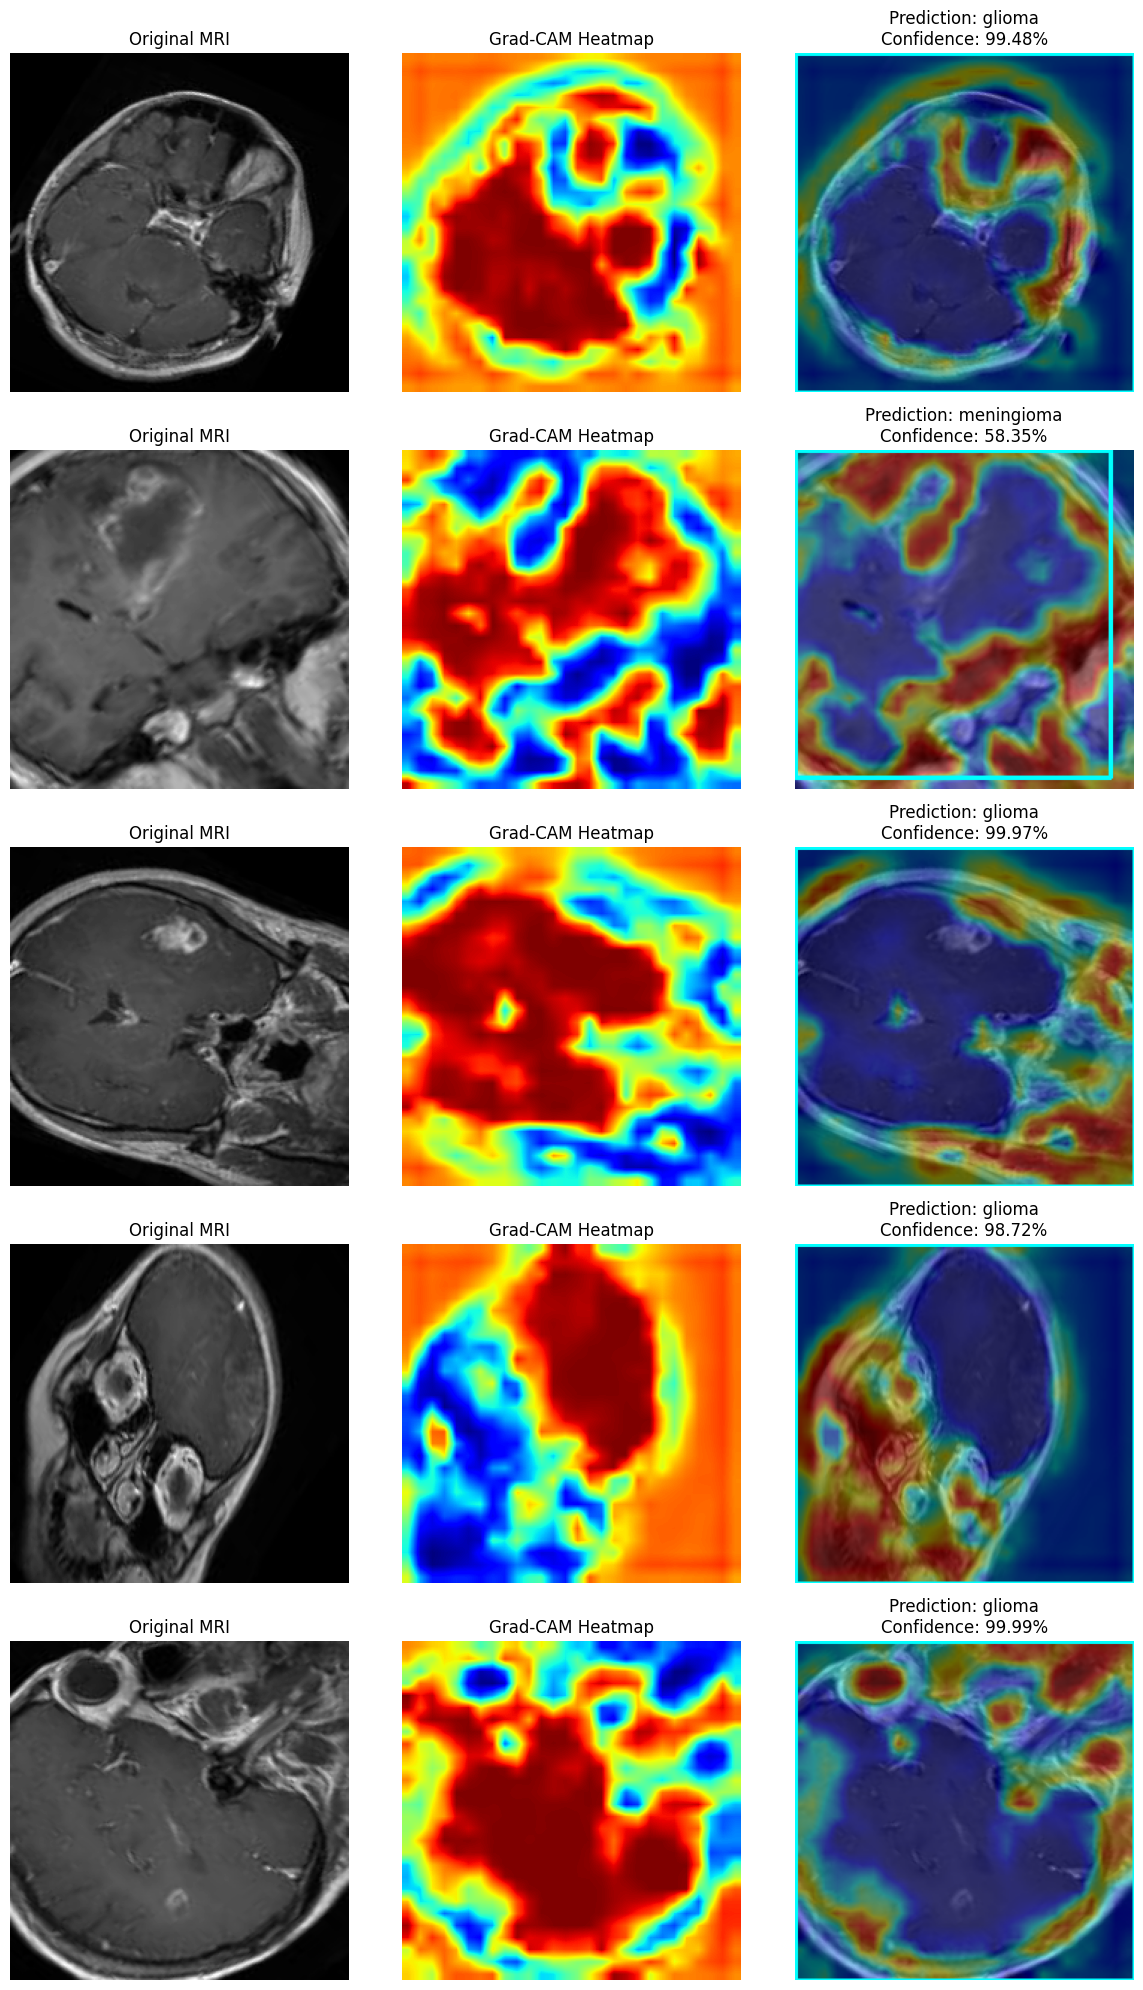

In [25]:

# ======================================================
# 17. SHOW VISUALIZATIONS ON SCREEN (5 samples)
# ======================================================
plt.figure(figsize=(12, 20))
valid_gen.reset()

for j in range(5):
    img, _ = valid_gen.next()
    img = img[0]
    img_exp = np.expand_dims(img, axis=0)

    preds = model.predict(img_exp, verbose=0)
    pred_class = np.argmax(preds)
    class_name = class_names[pred_class]
    confidence = np.max(preds)

    heatmap = make_gradcam_heatmap(img_exp, model, last_conv)
    heatmap_resized = cv2.resize(heatmap, (227,227))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    original = (img.squeeze() * 255).astype("uint8")
    original_rgb = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)

    overlay = cv2.addWeighted(original_rgb, 0.6, heatmap_color, 0.4, 0)

    # bounding box
    bbox = get_bounding_box(heatmap)
    if bbox:
        x,y,w,h = bbox
        cv2.rectangle(overlay, (x,y), (x+w,y+h), (0,255,255), 2)

    # ------- PLOT -------
    plt.subplot(5, 3, j*3 + 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(5, 3, j*3 + 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(5, 3, j*3 + 3)
    plt.imshow(overlay)
    plt.title(f"Prediction: {class_name}\nConfidence: {confidence*100:.2f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

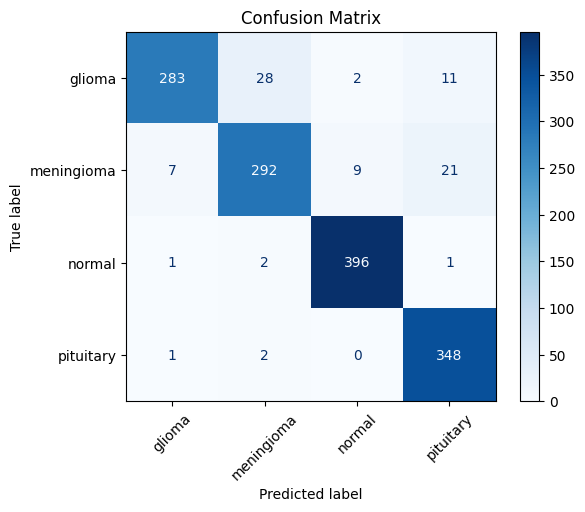

In [26]:
# ======================================================
# 18. Confusion Matrix
# ======================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [30]:
# ======================================================
# 19. Final Accuracy Table (Updated with Your Results)
# ======================================================

final_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Your Model": [
        0.94,   # accuracy
        0.94,   # precision
        0.94,   # recall
        0.94    # f1-score
    ]
    
})

print("\n PERFORMANCE COMPARISON TABLE:\n")
print(final_table.to_string(index=False))



 PERFORMANCE COMPARISON TABLE:

   Metric  Your Model
 Accuracy        0.94
Precision        0.94
   Recall        0.94
 F1-score        0.94


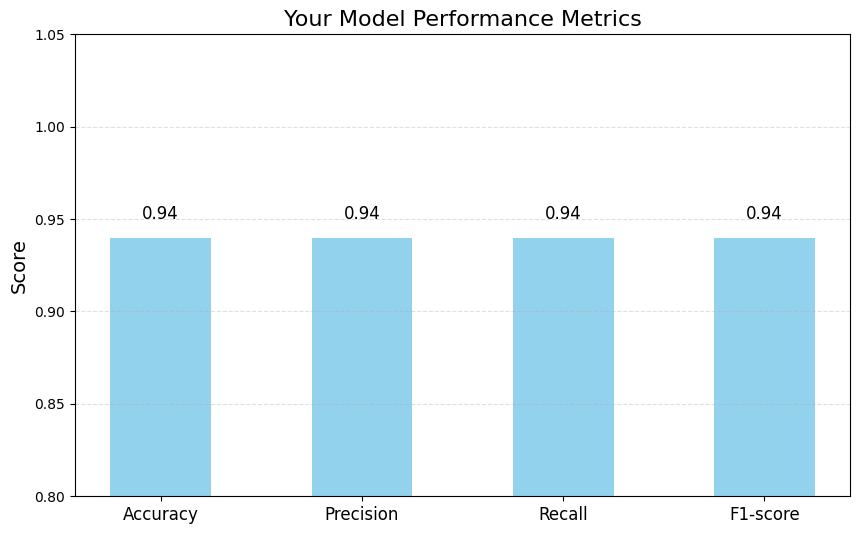

In [31]:
# ======================================================
# 20. Bar Graph: Your Model Performance Only
# ======================================================

import matplotlib.pyplot as plt
import numpy as np

# Your updated metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
your_scores = [0.94, 0.94, 0.94, 0.94]

x = np.arange(len(metrics))
width = 0.5

plt.figure(figsize=(10,6))
plt.bar(x, your_scores, width, color='skyblue', alpha=0.9)

plt.xticks(x, metrics, fontsize=12)
plt.ylabel("Score", fontsize=14)
plt.title("Your Model Performance Metrics", fontsize=16)
plt.ylim(0.8, 1.05)

# Display values above bars
for i, score in enumerate(your_scores):
    plt.text(i, score + 0.01, f"{score:.2f}", ha='center', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


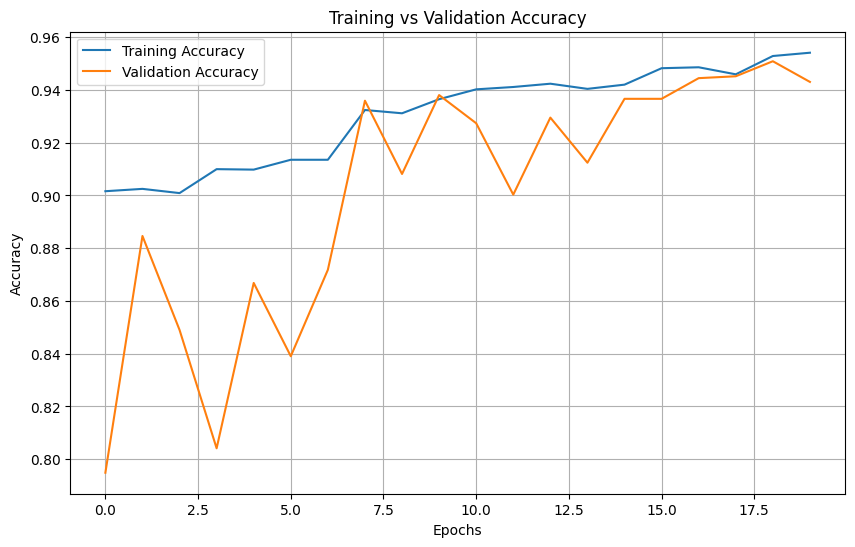

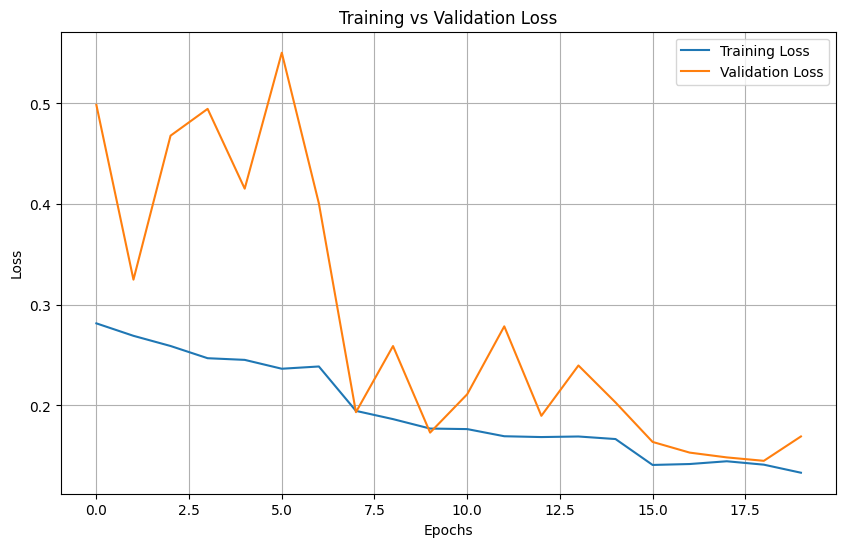

In [32]:

# ======================================================
# 21. Training vs Validation Accuracy Curve
# ======================================================

# Assuming you have a history object from model.fit()
# Example:
# history = model.fit(...)

plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ======================================================
# 22. Training vs Validation Loss Curve
# ======================================================

plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()